In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [22]:
df = pd.read_csv("../data/raw/HDFCBANK.NS_stock.csv")

In [23]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,595.6771240234375,596.3293706466624,591.9500654568958,594.5124182213932,3673698
3,2020-01-02,599.47412109375,600.0564740382747,595.8635328376968,595.8635328376968,6137166
4,2020-01-03,590.92529296875,598.6589300292867,588.6890345286461,597.3544364608236,10855550


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1613 entries, 0 to 1612
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1613 non-null   str  
 1   Close   1612 non-null   str  
 2   High    1612 non-null   str  
 3   Low     1612 non-null   str  
 4   Open    1612 non-null   str  
 5   Volume  1612 non-null   str  
dtypes: str(6)
memory usage: 210.6 KB


In [25]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1613
Columns: 6


In [26]:
df.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [27]:
df.dropna(inplace=True)

In [28]:
df.dtypes

Price     str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

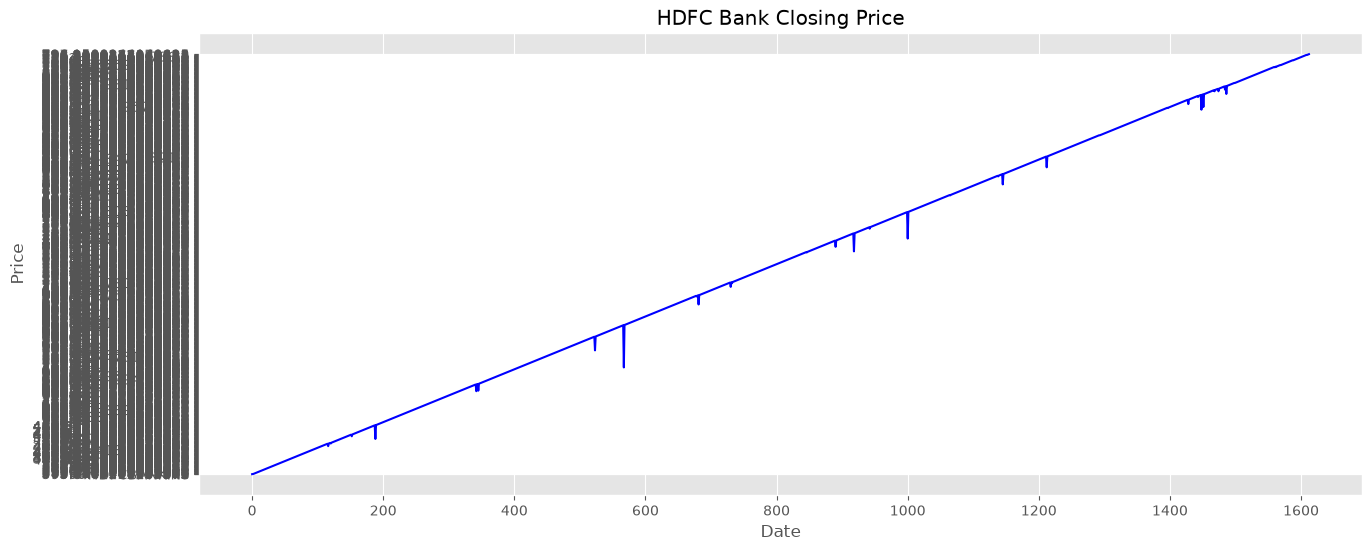

In [29]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Close"], color="blue")

plt.title("HDFC Bank Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

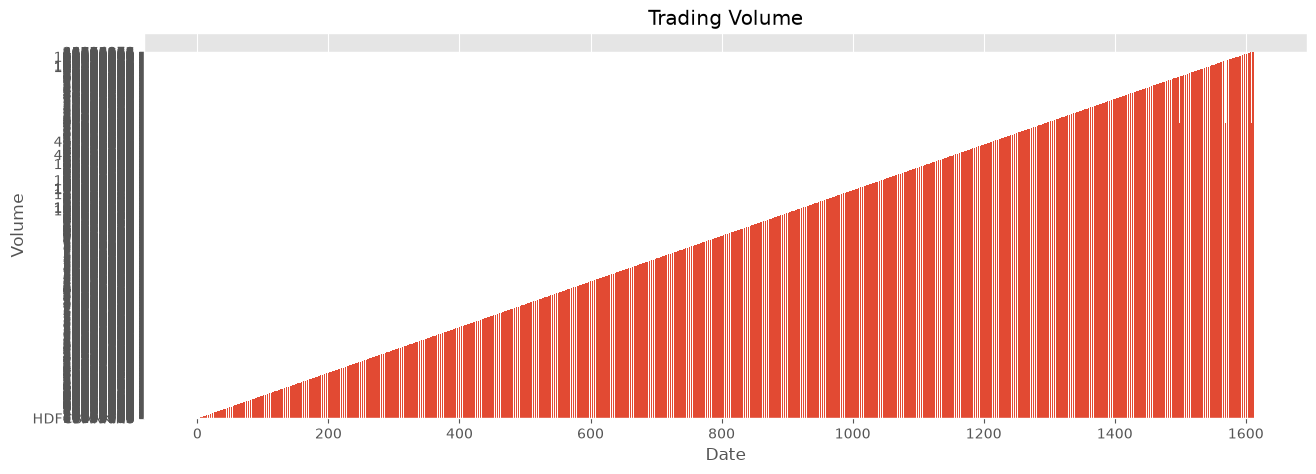

In [30]:
plt.figure(figsize=(15,5))

plt.bar(df.index, df["Volume"])

plt.title("Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.show()

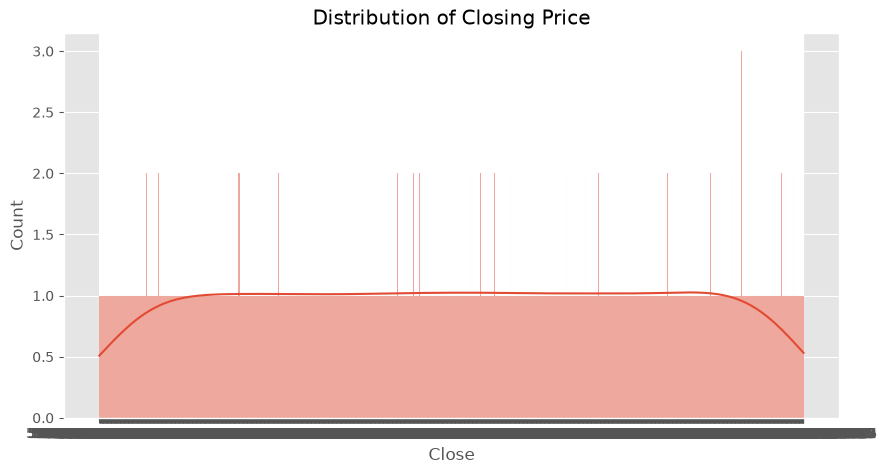

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(df["Close"], bins=40, kde=True)

plt.title("Distribution of Closing Price")

plt.show()

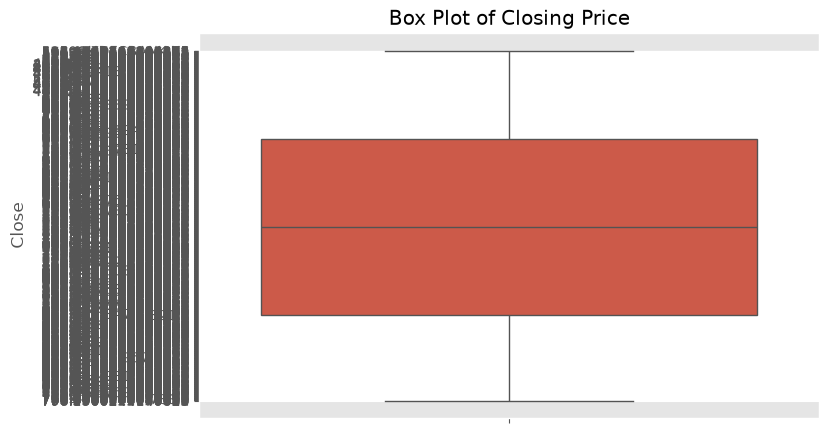

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Close"])

plt.title("Box Plot of Closing Price")

plt.show()

In [34]:
cols = ["Open", "High", "Low", "Close", "Volume"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [35]:
df["Daily_Return"] = df["Close"].pct_change()

In [36]:
df.head()

,Price,Close,High,Low,Open,Volume,Daily_Return
0,Ticker,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,595.677124,596.329371,591.950065,594.512418,3673698.0,NaN
3,2020-01-02,599.474121,600.056474,595.863533,595.863533,6137166.0,0.006374
4,2020-01-03,590.925293,598.658930,588.689035,597.354436,10855550.0,-0.014261
5,2020-01-06,578.136780,587.850474,575.830685,587.011863,10890186.0,-0.021642


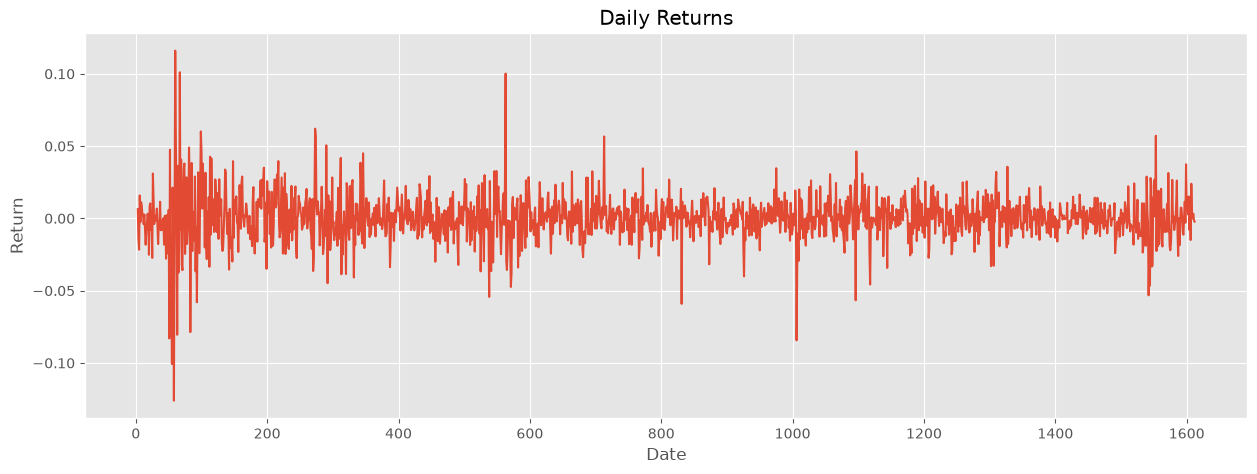

In [37]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["Daily_Return"])

plt.title("Daily Returns")

plt.xlabel("Date")

plt.ylabel("Return")

plt.show()

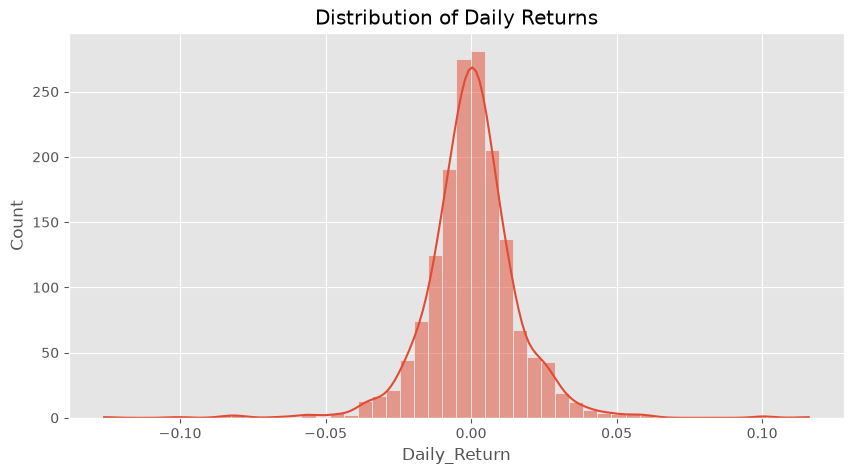

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(df["Daily_Return"].dropna(), bins=50, kde=True)

plt.title("Distribution of Daily Returns")

plt.show()

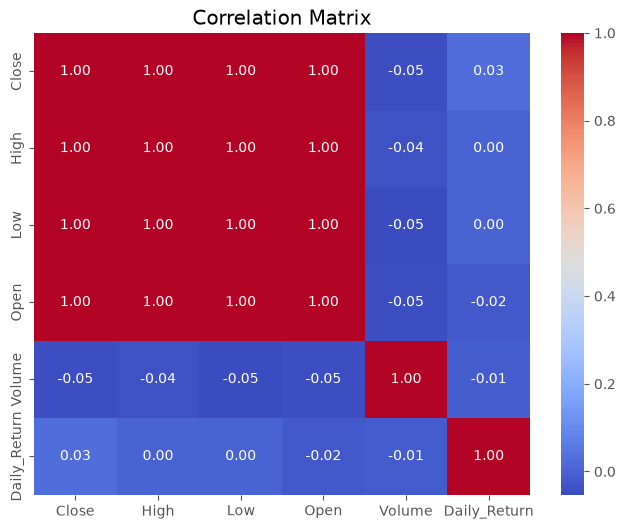

In [39]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [40]:
df.to_csv("../data/processed/HDFCBANK_cleaned.csv")